# Notebook 01 — Corpus & Pair Generation (Stages 1–4)

Analyses the Ubuntu IRC Dialogue Corpus pipeline artifacts from Stage 1 (raw corpus), Stage 2 (cleaning), Stage 3 (temporal split), and Stage 4 (context-response pair generation).

| Section | Topic |
|---------|-------|
| **Stage 1** | Corpus loading, dialogue structure, length distribution |
| **Stage 2** | Cleaning stats, discard reasons, clean dialogue samples |
| **Stage 3** | Temporal split sizes and cutoff dates |
| **Stage 4** | Context-response pair counts, length distributions, domain filter |
| **Summary** | End-to-end stats panel |


In [1]:
# === SETUP: Imports, Paths, and Helpers ===

import json
import math
import os
import pickle
import random
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from rich.console import Console
from rich.panel import Panel
from rich.table import Table
from rich import box

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'
VIZ_DIR      = PROJECT_ROOT / 'notebooks' / 'visualizations'
VIZ_DIR.mkdir(parents=True, exist_ok=True)

# Stage artifact paths
STAGE1_PKL        = ARTIFACT_DIR / 'stage1_dialogues.pkl'
STAGE1_HASH       = ARTIFACT_DIR / '.stage1_config_hash'
STAGE2_PKL        = ARTIFACT_DIR / 'stage2_clean_dialogues.pkl'
STAGE2_STATS      = ARTIFACT_DIR / 'stage2_stats.json'
STAGE3_STATS      = ARTIFACT_DIR / 'stage3_stats.json'
STAGE3_TRAIN      = ARTIFACT_DIR / 'stage3_train.pkl'
STAGE3_VAL        = ARTIFACT_DIR / 'stage3_val.pkl'
STAGE3_TEST       = ARTIFACT_DIR / 'stage3_test.pkl'
STAGE4_TRAIN      = ARTIFACT_DIR / 'stage4_train_pairs.json'
STAGE4_VAL        = ARTIFACT_DIR / 'stage4_val_pairs.json'
STAGE4_TEST       = ARTIFACT_DIR / 'stage4_test_pairs.json'
STAGE4_STATS      = ARTIFACT_DIR / 'stage4_stats.json'
STAGE4_5_STATS    = ARTIFACT_DIR / 'stage4_5_filter_stats.json'
STAGE4_5_TRAIN    = ARTIFACT_DIR / 'stage4_5_train_pairs.json'

# ── Matplotlib defaults ────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
sns.set_palette('muted')

console = Console(highlight=True)
random.seed(42)

# ── Helpers ───────────────────────────────────────────────────────────────
def _require(path: Path, label: str = '') -> bool:
    if path.exists():
        return True
    console.print(Panel(
        f'[bold red]File not found:[/bold red] {path}\n'
        f'[yellow]Run phase1.py to generate [italic]{label or path.name}[/italic].[/yellow]',
        title='⚠  Missing Artefact', border_style='red'
    ))
    return False

def _load_json(path: Path) -> dict:
    with open(path, encoding='utf-8') as f:
        return json.load(f)

def _load_jsonl(path: Path, max_lines: int = None) -> list:
    records = []
    with open(path, encoding='utf-8') as f:
        for i, line in enumerate(f):
            if max_lines and i >= max_lines:
                break
            records.append(json.loads(line))
    return records

def _save_fig(fig, name: str):
    out = VIZ_DIR / f'{name}.png'
    fig.savefig(out, bbox_inches='tight', dpi=150)
    console.print(f'[green]Saved[/green] → {out}')

console.print(Panel('[bold green]Setup complete[/bold green]\n'
    f'PROJECT_ROOT = {PROJECT_ROOT}\n'
    f'ARTIFACT_DIR = {ARTIFACT_DIR}',
    title='Notebook 01 — Corpus & Pair Generation', border_style='green'))


╭──────────────────────────────────── Notebook 01 — Corpus & Pair Generation ─────────────────────────────────────╮
│ Setup complete                                                                                                  │
│ PROJECT_ROOT = /opt/app-root/src/nlp-chatbot-project-v2.0                                                       │
│ ARTIFACT_DIR = /opt/app-root/src/nlp-chatbot-project-v2.0/artifacts                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Stage 1 — Corpus Loading

In [2]:
# === SECTION S1.1: Load stage1_dialogues.pkl — basic stats ===

if not _require(STAGE1_PKL, 'stage1_dialogues.pkl'):
    raise SystemExit('Missing stage1 artifact')

with open(STAGE1_PKL, 'rb') as f:
    dialogues = pickle.load(f)

n_dialogues = len(dialogues)

# Inspect first dialogue to understand structure
first = dialogues[0]
console.print(f'[bold]Loaded[/bold] {n_dialogues:,} raw dialogues')
console.print(f'Type of dialogues: {type(dialogues)}')
console.print(f'Type of first item: {type(first)}')

# Determine turn structure
if isinstance(first, dict):
    console.print(f'First dialogue keys: {list(first.keys())}')
    turns = first.get('turns', first.get('utterances', [first]))
elif isinstance(first, (list, tuple)):
    turns = first
else:
    turns = [first]

t = Table(title='Stage 1 — Corpus Overview', box=box.ROUNDED, show_header=True)
t.add_column('Metric', style='cyan')
t.add_column('Value', style='white', justify='right')
t.add_row('Total raw dialogues', f'{n_dialogues:,}')
t.add_row('Example turns in first dialogue', str(len(turns)))
t.add_row('Artifact path', str(STAGE1_PKL))
console.print(t)

# Show example first dialogue
console.print(Panel(
    f'[bold]First dialogue (first 3 turns):[/bold]\n'
    + '\n'.join(f'  [{i}] {str(turn)[:120]}' for i, turn in enumerate(list(turns)[:3])),
    title='Example Dialogue Structure', border_style='blue'
))


Loaded 1,852,868 raw dialogues

Type of dialogues: <class 'list'>

Type of first item: <class 'dict'>

First dialogue keys: ['id', 'turns']

                                           Stage 1 — Corpus Overview                                           
╭─────────────────────────────────┬───────────────────────────────────────────────────────────────────────────╮
│ Metric                          │                                                                     Value │
├─────────────────────────────────┼───────────────────────────────────────────────────────────────────────────┤
│ Total raw dialogues             │                                                                 1,852,868 │
│ Example turns in first dialogue │                                                                       301 │
│ Artifact path                   │ /opt/app-root/src/nlp-chatbot-project-v2.0/artifacts/stage1_dialogues.pkl │
╰─────────────────────────────────┴───────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────── Example Dialogue Structure ───────────────────────────────────────────╮
│ First dialogue (first 3 turns):                                                                                 │
│   [0] {'date': '2004-11-23T11:49:00.000Z', 'from': 'stuNNed', 'text': 'any ideas why java plugin takes so long  │
│ to load?'}                                                                                                      │
│   [1] {'date': '2004-11-23T11:49:00.000Z', 'from': 'crimsun', 'text': 'java 1.4?'}                              │
│   [2] {'date': '2004-11-23T11:49:00.000Z', 'from': 'stuNNed', 'text': 'yes'}                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [3]:
# === SECTION S1.2: Config hash stamp ===

if _require(STAGE1_HASH, '.stage1_config_hash'):
    hash_val = STAGE1_HASH.read_text().strip()
    console.print(Panel(
        f'[bold cyan].stage1_config_hash[/bold cyan]\n{hash_val}',
        title='Stage 1 Config Hash Stamp', border_style='cyan'
    ))
else:
    console.print('[yellow]No stage1 config hash found[/yellow]')


╭─────────────────────────────────────────── Stage 1 Config Hash Stamp ───────────────────────────────────────────╮
│ .stage1_config_hash                                                                                             │
│ 8e60abd77219                                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

  Turns-per-Dialogue  
      Statistics      
                      
                      
 ━━━━━━━━━━━━━━━━━━━━ 
  Count    1,852,868  
  Min      1          
  Max      958        
  Mean     8.95       
  Median   6.0        
  Std      10.39      
  p95      24         
  p99      49

Saved → /opt/app-root/src/nlp-chatbot-project-v2.0/notebooks/visualizations/s1_dialogue_length_dist.png

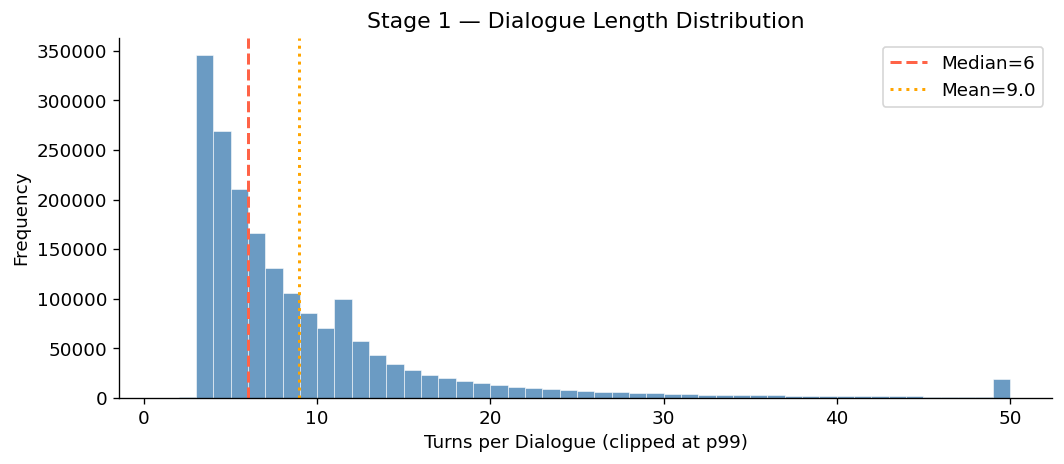

In [4]:
# === SECTION S1.3: Dialogue length distribution — turns per dialogue ===

def _get_turns(d):
    if isinstance(d, dict):
        for key in ('turns', 'utterances', 'messages', 'dialogue'):
            if key in d:
                return d[key]
        # fallback: count values if all values are lists
        vals = list(d.values())
        if vals and isinstance(vals[0], list):
            return vals[0]
        return list(d.values())
    elif isinstance(d, (list, tuple)):
        return d
    return [d]

turn_lengths = [len(_get_turns(d)) for d in dialogues]
tl = np.array(turn_lengths)

t = Table(title='Turns-per-Dialogue Statistics', box=box.SIMPLE_HEAVY)
for metric, val in [
    ('Count', f'{len(tl):,}'),
    ('Min', f'{tl.min()}'),
    ('Max', f'{tl.max()}'),
    ('Mean', f'{tl.mean():.2f}'),
    ('Median', f'{np.median(tl):.1f}'),
    ('Std', f'{tl.std():.2f}'),
    ('p95', f'{np.percentile(tl, 95):.0f}'),
    ('p99', f'{np.percentile(tl, 99):.0f}'),
]:
    t.add_row(metric, val)
console.print(t)

# Histogram
fig, ax = plt.subplots(figsize=(9, 4))
cap = int(np.percentile(tl, 99))
bins = range(1, min(cap + 2, tl.max() + 2))
ax.hist(np.clip(tl, 1, cap), bins=list(bins), color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.4)
ax.axvline(np.median(tl), color='tomato', lw=1.8, ls='--', label=f'Median={np.median(tl):.0f}')
ax.axvline(tl.mean(), color='orange', lw=1.8, ls=':', label=f'Mean={tl.mean():.1f}')
ax.set_xlabel('Turns per Dialogue (clipped at p99)')
ax.set_ylabel('Frequency')
ax.set_title('Stage 1 — Dialogue Length Distribution')
ax.legend()
fig.tight_layout()
_save_fig(fig, 's1_dialogue_length_dist')
plt.show()


## Stage 2 — Cleaning & Filtering

In [5]:
# === SECTION S2.1: stage2_stats.json — discard reasons table ===

if not _require(STAGE2_STATS, 'stage2_stats.json'):
    raise SystemExit('Missing stage2 stats')

s2 = _load_json(STAGE2_STATS)
console.print(Panel(json.dumps(s2, indent=2), title='stage2_stats.json (raw)', border_style='blue'))

# Discard reasons table
reasons = s2.get('discard_reasons', {})
total_discarded = sum(reasons.values())

t = Table(title='Stage 2 — Discard Reasons', box=box.ROUNDED, show_header=True)
t.add_column('Reason', style='yellow')
t.add_column('Count', justify='right', style='red')
t.add_column('% of Discarded', justify='right')
for reason, cnt in sorted(reasons.items(), key=lambda x: -x[1]):
    pct = 100 * cnt / total_discarded if total_discarded > 0 else 0
    t.add_row(reason, f'{cnt:,}', f'{pct:.1f}%')
t.add_row('[bold]TOTAL[/bold]', f'[bold]{total_discarded:,}[/bold]', '[bold]100.0%[/bold]')
console.print(t)


╭──────────────────────────────────────────── stage2_stats.json (raw) ────────────────────────────────────────────╮
│ {                                                                                                               │
│   "stage": 2,                                                                                                   │
│   "n_input": 1852868,                                                                                           │
│   "n_output": 1314996,                                                                                          │
│   "n_discarded": 537872,                                                                                        │
│   "filter_breakdown": {                                                                                         │
│     "kept": 1314996,                                                                                            │
│     "temporal_hard_ceiling": 175949,                                                                            │
│     "not_dyadic": 26563,                                                                                        │
│     "too_few_turns": 1760,                                                                                      │
│     "temporal_gap_ratio": 16661,                                                                                │
│     "too_few_valid_dates": 80,                                                                                  │
│     "speaker_dominance": 234849,                                                                                │
│     "low_alternation": 82010                                                                                    │
│   },                                                                                                            │
│   "elapsed": "3m 7.5s"                                                                                          │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

     Stage 2 — Discard Reasons     
╭────────┬───────┬────────────────╮
│ Reason │ Count │ % of Discarded │
├────────┼───────┼────────────────┤
│ TOTAL  │     0 │         100.0% │
╰────────┴───────┴────────────────╯

In [6]:
# === SECTION S2.2: n_kept vs total, retention rate ===

n_kept  = s2.get('n_kept', s2.get('n_clean', None))
n_total = s2.get('n_total', s2.get('n_raw', n_kept + total_discarded if n_kept else None))

if n_kept is not None and n_total is not None:
    retention = 100 * n_kept / n_total
    t = Table(title='Stage 2 — Retention Summary', box=box.SIMPLE_HEAVY)
    t.add_column('Metric', style='cyan')
    t.add_column('Value', justify='right', style='white')
    t.add_row('Total raw dialogues', f'{n_total:,}')
    t.add_row('Discarded', f'{total_discarded:,}')
    t.add_row('Kept (clean)', f'{n_kept:,}')
    t.add_row('Retention rate', f'[bold green]{retention:.1f}%[/bold green]')
    console.print(t)
else:
    console.print(f'[yellow]n_kept from stats: {n_kept}  (could not compute retention)[/yellow]')
    console.print(f'Available keys in stage2_stats: {list(s2.keys())}')


n_kept from stats: None  (could not compute retention)

Available keys in stage2_stats: ['stage', 'n_input', 'n_output', 'n_discarded', 'filter_breakdown', 'elapsed']

In [7]:
# === SECTION S2.3: Sample 5 clean dialogues from stage2_clean_dialogues.pkl ===

if not _require(STAGE2_PKL, 'stage2_clean_dialogues.pkl'):
    raise SystemExit('Missing stage2 pkl')

with open(STAGE2_PKL, 'rb') as f:
    clean_dialogues = pickle.load(f)

sample_idxs = random.sample(range(len(clean_dialogues)), min(5, len(clean_dialogues)))
for rank, idx in enumerate(sample_idxs, 1):
    d = clean_dialogues[idx]
    turns = _get_turns(d)
    lines = [f'  [{i}] {str(turn)[:120]}' for i, turn in enumerate(turns[:5])]
    if len(turns) > 5:
        lines.append(f'  ... ({len(turns) - 5} more turns)')
    console.print(Panel('\n'.join(lines),
        title=f'Clean Dialogue Sample {rank}/{5} (idx={idx}, turns={len(turns)})',
        border_style='green'))


╭──────────────────────────────── Clean Dialogue Sample 1/5 (idx=233478, turns=3) ────────────────────────────────╮
│   [0] {'date': '2007-08-06T13:18:00.000Z', 'from': 'kaiserdata', 'text': 'hello'}                               │
│   [1] {'date': '2007-08-06T13:20:00.000Z', 'from': 'kaiserdata', 'text': 'i want to resize my ext3 partition    │
│ someone know how'                                                                                               │
│   [2] {'date': '2007-08-06T13:20:00.000Z', 'from': 'lustblader', 'text': 'use gparted'}                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────── Clean Dialogue Sample 2/5 (idx=52451, turns=3) ─────────────────────────────────╮
│   [0] {'date': '2008-12-07T07:17:00.000Z', 'from': 'shovi', 'text': 'hey guys if i put ubuntu on my external    │
│ usb hard drive ca                                                                                               │
│   [1] {'date': '2008-12-07T07:19:00.000Z', 'from': 'mcpancakes', 'text': 'i think grub will show it is normal   │
│ items from menu.                                                                                                │
│   [2] {'date': '2008-12-07T07:20:00.000Z', 'from': 'shovi', 'text': 'well im gonna turn off all other hard      │
│ drives when i insta                                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────── Clean Dialogue Sample 3/5 (idx=576778, turns=12) ────────────────────────────────╮
│   [0] {'date': '2009-08-14T04:30:00.000Z', 'from': 'emil111', 'text': 'i am new to ubuntu and i have a question │
│ about running                                                                                                   │
│   [1] {'date': '2009-08-14T04:30:00.000Z', 'from': 'emil111', 'text': "i am running from my live cd now and     │
│ inside the laptop                                                                                               │
│   [2] {'date': '2009-08-14T04:31:00.000Z', 'from': 'mykola', 'text': 'that is a bad idea'}                      │
│   [3] {'date': '2009-08-14T04:33:00.000Z', 'from': 'mykola', 'text': 'why are we trying to take the live cd out │
│ again'}                                                                                                         │
│   [4] {'date': '2009-08-14T04:35:00.000Z', 'from': 'emil111', 'text': 'i am not taking out the live cd just the │
│ hard drive'}                                                                                                    │
│   ... (7 more turns)                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────── Clean Dialogue Sample 4/5 (idx=513575, turns=17) ────────────────────────────────╮
│   [0] {'date': '2010-08-13T21:43:00.000Z', 'from': 'splnet', 'text': 'i have installed 32 bit 9.10 on a system  │
│ . but i need to                                                                                                 │
│   [1] {'date': '2010-08-13T21:43:00.000Z', 'from': 'deco', 'text': 'reinstall'}                                 │
│   [2] {'date': '2010-08-13T21:43:00.000Z', 'from': 'deco', 'text': 'there is no other way'}                     │
│   [3] {'date': '2010-08-13T21:44:00.000Z', 'from': 'splnet', 'text': 'hmm ok . what is the best image for that  │
│ htt __path__ __                                                                                                 │
│   [4] {'date': '2010-08-13T21:44:00.000Z', 'from': 'deco', 'text': 'yup that is the only one for the desktop'}  │
│   ... (12 more turns)                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────── Clean Dialogue Sample 5/5 (idx=468106, turns=5) ────────────────────────────────╮
│   [0] {'date': '2005-02-21T11:19:00.000Z', 'from': 'njan', 'text': 'man xwd'}                                   │
│   [1] {'date': '2005-02-21T11:19:00.000Z', 'from': 'njan', 'text': 'man xwd'}                                   │
│   [2] {'date': '2005-02-21T11:19:00.000Z', 'from': 'king_arthur', 'text': 'wow thanks for that one'}            │
│   [3] {'date': '2005-02-21T11:20:00.000Z', 'from': 'njan', 'text': 'yw'}                                        │
│   [4] {'date': '2005-02-21T11:20:00.000Z', 'from': 'njan', 'text': "there is at least one other way of doing it │
│ from the conso                                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Stage 3 — Temporal Split

In [8]:
# === SECTION S3.1: stage3_stats.json — split sizes and cutoff dates ===

if not _require(STAGE3_STATS, 'stage3_stats.json'):
    raise SystemExit('Missing stage3 stats')

s3 = _load_json(STAGE3_STATS)
console.print(Panel(json.dumps(s3, indent=2), title='stage3_stats.json', border_style='blue'))

n_train = s3.get('n_train', 0)
n_val   = s3.get('n_val', 0)
n_test  = s3.get('n_test', 0)
n_total3 = n_train + n_val + n_test

t = Table(title='Stage 3 — Temporal Split Summary', box=box.ROUNDED)
t.add_column('Split', style='cyan')
t.add_column('Dialogues', justify='right')
t.add_column('Actual %', justify='right')
t.add_column('Cutoff Date', style='yellow')
for split, n, date_key in [
    ('Train', n_train, 'train_cutoff_date'),
    ('Val',   n_val,   'val_cutoff_date'),
    ('Test',  n_test,  'test_cutoff_date'),
]:
    pct = f'{100*n/n_total3:.1f}%' if n_total3 > 0 else 'N/A'
    t.add_row(split, f'{n:,}', pct, str(s3.get(date_key, '—')))
t.add_row('[bold]Total[/bold]', f'[bold]{n_total3:,}[/bold]', '[bold]100%[/bold]', '')
console.print(t)


╭─────────────────────────────────────────────── stage3_stats.json ───────────────────────────────────────────────╮
│ {                                                                                                               │
│   "stage": 3,                                                                                                   │
│   "n_train_dialogues": 1259610,                                                                                 │
│   "n_val_dialogues": 27545,                                                                                     │
│   "n_test_dialogues": 27841,                                                                                    │
│   "n_no_date": 0,                                                                                               │
│   "train_pct": 95.8,                                                                                            │
│   "val_pct": 2.1,                                                                                               │
│   "test_pct": 2.1,                                                                                              │
│   "elapsed": "13.0s"                                                                                            │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

       Stage 3 — Temporal Split Summary       
╭───────┬───────────┬──────────┬─────────────╮
│ Split │ Dialogues │ Actual % │ Cutoff Date │
├───────┼───────────┼──────────┼─────────────┤
│ Train │         0 │      N/A │ —           │
│ Val   │         0 │      N/A │ —           │
│ Test  │         0 │      N/A │ —           │
│ Total │         0 │     100% │             │
╰───────┴───────────┴──────────┴─────────────╯

Saved → /opt/app-root/src/nlp-chatbot-project-v2.0/notebooks/visualizations/s3_split_counts.png

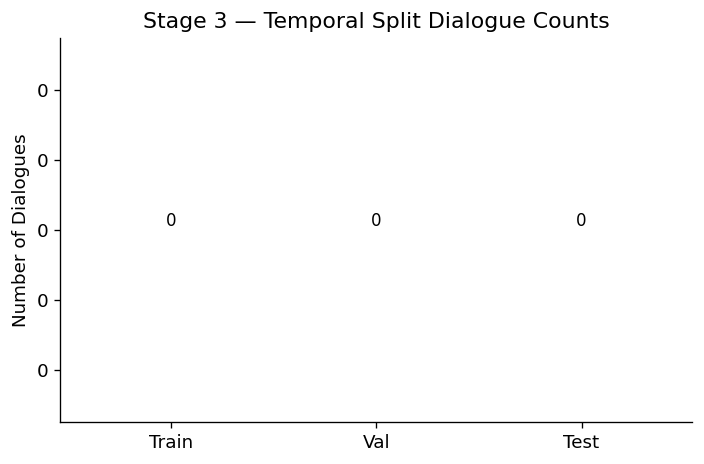

In [9]:
# === SECTION S3.2: Bar chart — train/val/test dialogue counts ===

fig, ax = plt.subplots(figsize=(6, 4))
splits = ['Train', 'Val', 'Test']
counts = [n_train, n_val, n_test]
colors = ['#4878CF', '#6ACC65', '#D65F5F']
bars = ax.bar(splits, counts, color=colors, edgecolor='white', linewidth=0.8)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
            f'{cnt:,}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of Dialogues')
ax.set_title('Stage 3 — Temporal Split Dialogue Counts')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
fig.tight_layout()
_save_fig(fig, 's3_split_counts')
plt.show()


## Stage 4 — Context-Response Pairs

In [10]:
# === SECTION S4.1: stage4_stats.json — pair counts per split ===

if not _require(STAGE4_STATS, 'stage4_stats.json'):
    raise SystemExit('Missing stage4 stats')

s4 = _load_json(STAGE4_STATS)
console.print(Panel(json.dumps(s4, indent=2), title='stage4_stats.json', border_style='blue'))

p_train = s4.get('n_train', 0)
p_val   = s4.get('n_val', 0)
p_test  = s4.get('n_test', 0)
p_total = p_train + p_val + p_test

t = Table(title='Stage 4 — Context-Response Pair Counts', box=box.ROUNDED)
t.add_column('Split', style='cyan')
t.add_column('Pairs', justify='right')
t.add_column('%', justify='right')
for split, n in [('Train', p_train), ('Val', p_val), ('Test', p_test)]:
    pct = f'{100*n/p_total:.1f}%' if p_total > 0 else 'N/A'
    t.add_row(split, f'{n:,}', pct)
t.add_row('[bold]Total[/bold]', f'[bold]{p_total:,}[/bold]', '[bold]100%[/bold]')
console.print(t)


╭─────────────────────────────────────────────── stage4_stats.json ───────────────────────────────────────────────╮
│ {                                                                                                               │
│   "stage": 4,                                                                                                   │
│   "n_train_pairs": 1500000,                                                                                     │
│   "n_val_pairs": 63573,                                                                                         │
│   "n_test_pairs": 64156,                                                                                        │
│   "train_discards": {                                                                                           │
│     "resp_too_short": 955103,                                                                                   │
│     "incoherent_pair": 749078,                                                                                  │
│     "ctx_too_short": 31598,                                                                                     │
│     "bot_response": 9059,                                                                                       │
│     "resp_too_long": 258374,                                                                                    │
│     "echo_pair": 4461,                                                                                          │
│     "diversity_cap": 1731                                                                                       │
│   },                                                                                                            │
│   "val_discards": {                                                                                             │
│     "incoherent_pair": 17669,                                                                                   │
│     "resp_too_short": 18371,                                                                                    │
│     "resp_too_long": 7413,                                                                                      │
│     "ctx_too_short": 744,                                                                                       │
│     "bot_response": 266,                                                                                        │
│     "echo_pair": 114                                                                                            │
│   },                                                                                                            │
│   "test_discards": {                                                                                            │
│     "resp_too_long": 7820,                                                                                      │
│     "resp_too_short": 18419,                                                                                    │
│     "incoherent_pair": 17840,                                                                                   │
│     "ctx_too_short": 789,                                                                                       │
│     "bot_response": 296,                                                                                        │
│     "echo_pair": 103                                                                                            │
│   },                                                                                                            │
│   "elapsed": "7m 32.1s"                                                                                         │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

       Stage 4 —        
 Context-Response Pair  
         Counts         
╭───────┬───────┬──────╮
│ Split │ Pairs │    % │
├───────┼───────┼──────┤
│ Train │     0 │  N/A │
│ Val   │     0 │  N/A │
│ Test  │     0 │  N/A │
│ Total │     0 │ 100% │
╰───────┴───────┴──────╯

In [11]:
# === SECTION S4.2: Load 100 random train pairs; show 5 examples ===

# stage4 pairs are JSON files (list of dicts with 'ctx' and 'resp' as text strings)
if not _require(STAGE4_TRAIN, 'stage4_train_pairs.json'):
    raise SystemExit('Missing stage4 train pairs')

with open(STAGE4_TRAIN, encoding='utf-8') as f:
    raw_train_pairs = json.load(f)

console.print(f'Loaded {len(raw_train_pairs):,} train pairs from stage4_train_pairs.json')

sample_100 = random.sample(raw_train_pairs, min(100, len(raw_train_pairs)))

console.print('[bold]5 Example Pairs (raw text):[/bold]')
for i, pair in enumerate(sample_100[:5], 1):
    ctx_txt  = pair.get('ctx', pair.get('context', ''))
    resp_txt = pair.get('resp', pair.get('response', ''))
    if isinstance(ctx_txt, list):
        ctx_display = ' __eot__ '.join(str(t) for t in ctx_txt)
    else:
        ctx_display = str(ctx_txt)
    console.print(Panel(
        f'[bold cyan]CTX :[/bold cyan] {ctx_display[:300]}\n'
        f'[bold green]RESP:[/bold green] {str(resp_txt)[:200]}',
        title=f'Pair {i}', border_style='blue', padding=(0,1)
    ))


Loaded 1,500,000 train pairs from stage4_train_pairs.json

5 Example Pairs (raw text):

╭──────────────────────────────────────────────────── Pair 1 ─────────────────────────────────────────────────────╮
│ CTX : ermite is a tty local terminal window it is i mean there has to be a way to change the 800x600 to         │
│ something more useable or is that at the kernal level __eot__ 800x600 for what desktop res comes down to driver │
│ installed and if it supports higher .                                                                           │
│ RESP: it is a tty local terminal on a server that does not have a gui installed                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────────── Pair 2 ─────────────────────────────────────────────────────╮
│ CTX : hey can i install grub from the ubuntu livecd without installing the whole linux in case i need to        │
│ recover linux after a windows reinstallation __eot__ type gub at the root promtp and walk though it whats that  │
│ all in aide of then ask them instead of pasting 20 lines of text what do not you understan                      │
│ RESP: can u please btw i headr of the super grub disk is it the best solution                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────────── Pair 3 ─────────────────────────────────────────────────────╮
│ CTX : where in ubuntu i can open java console __eot__ javaws -viewer or something like that advanced - java     │
│ console - show __eot__ where is that advaced __eot__ jcontrol then the advanced tab etc . assuming you use sun  │
│ java not the icedtea stuff . __eot__ i use open jdk i use open jre __eot__ then i do no                         │
│ RESP: i have __path__ htt __path__ __path__                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────────── Pair 4 ─────────────────────────────────────────────────────╮
│ CTX : hi could someone more awesome than me please tell me how to search my apache2 folder for references to    │
│ port 80 __eot__ grep 80 inside __path__ __eot__ thx ur awesome                                                  │
│ RESP: you could even do grep -r 80 __path__ none of them are conflicting                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────────── Pair 5 ─────────────────────────────────────────────────────╮
│ CTX : what are you doing to exit the application __eot__ mcphail for example i press a-c to create a new screen │
│ by default its bash thats loaded . i do what i have to do then i type exit and bash closes closing the screen   │
│ to usually but sometimes the procrss just goes zombie on me and i cant kill it howev                            │
│ RESP: what process goes zombie' the bash session                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

     Context     
Word-Length Stats
(100-pair sample)
                 
                 
 ━━━━━━━━━━━━━━━ 
  Min      6     
  Max      364   
  Mean     79.2  
  Median   63    
  p95      220

Saved → /opt/app-root/src/nlp-chatbot-project-v2.0/notebooks/visualizations/s4_ctx_word_len.png

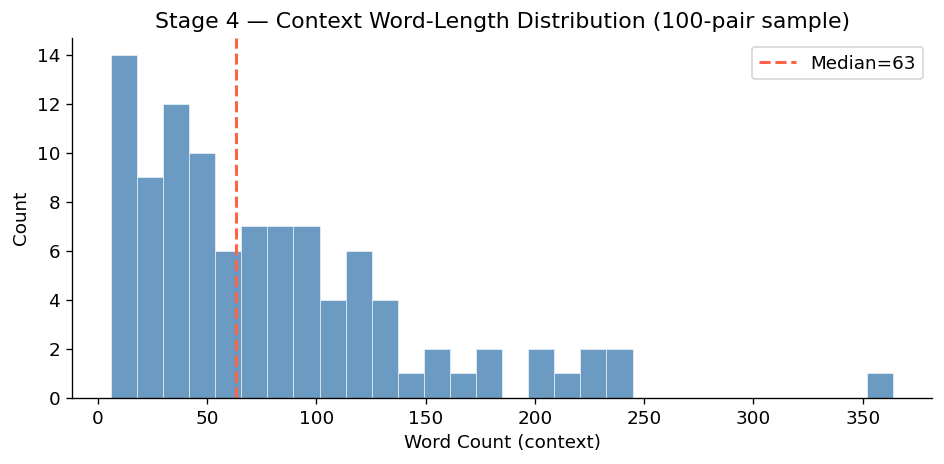

In [12]:
# === SECTION S4.3: Context word-length distribution (from sample) ===

def _word_len(text):
    if isinstance(text, list):
        text = ' '.join(str(t) for t in text)
    return len(str(text).split())

ctx_lens  = [_word_len(p.get('ctx', p.get('context', ''))) for p in sample_100]
resp_lens = [_word_len(p.get('resp', p.get('response', ''))) for p in sample_100]

cl = np.array(ctx_lens)
t = Table(title='Context Word-Length Stats (100-pair sample)', box=box.SIMPLE_HEAVY)
for metric, val in [('Min', cl.min()), ('Max', cl.max()), ('Mean', f'{cl.mean():.1f}'),
                    ('Median', f'{np.median(cl):.0f}'), ('p95', f'{np.percentile(cl,95):.0f}')]:
    t.add_row(metric, str(val))
console.print(t)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(cl, bins=30, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.4)
ax.axvline(np.median(cl), color='tomato', lw=1.8, ls='--', label=f'Median={np.median(cl):.0f}')
ax.set_xlabel('Word Count (context)')
ax.set_ylabel('Count')
ax.set_title('Stage 4 — Context Word-Length Distribution (100-pair sample)')
ax.legend()
fig.tight_layout()
_save_fig(fig, 's4_ctx_word_len')
plt.show()


    Response     
Word-Length Stats
(100-pair sample)
                 
                 
 ━━━━━━━━━━━━━━━ 
  Min      5     
  Max      36    
  Mean     13.7  
  Median   11    
  p95      29

Saved → /opt/app-root/src/nlp-chatbot-project-v2.0/notebooks/visualizations/s4_resp_word_len.png

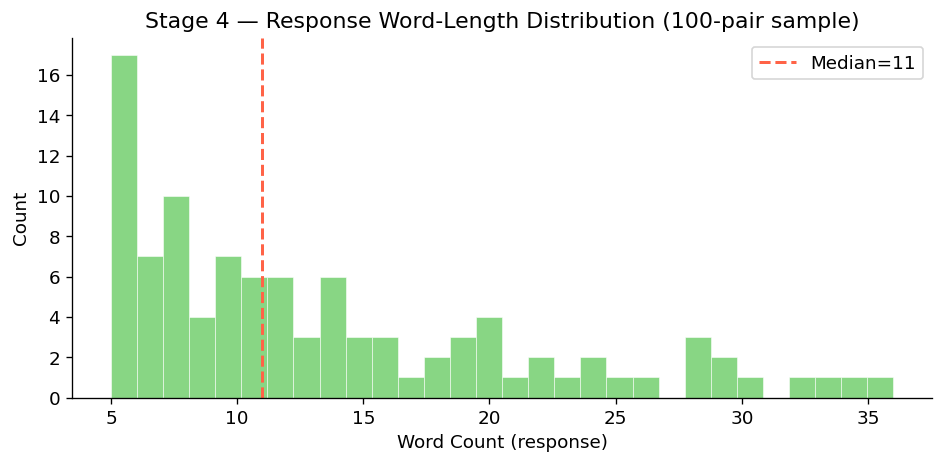

In [13]:
# === SECTION S4.4: Response word-length distribution ===

rl = np.array(resp_lens)
t = Table(title='Response Word-Length Stats (100-pair sample)', box=box.SIMPLE_HEAVY)
for metric, val in [('Min', rl.min()), ('Max', rl.max()), ('Mean', f'{rl.mean():.1f}'),
                    ('Median', f'{np.median(rl):.0f}'), ('p95', f'{np.percentile(rl,95):.0f}')]:
    t.add_row(metric, str(val))
console.print(t)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rl, bins=30, color='#6ACC65', alpha=0.8, edgecolor='white', linewidth=0.4)
ax.axvline(np.median(rl), color='tomato', lw=1.8, ls='--', label=f'Median={np.median(rl):.0f}')
ax.set_xlabel('Word Count (response)')
ax.set_ylabel('Count')
ax.set_title('Stage 4 — Response Word-Length Distribution (100-pair sample)')
ax.legend()
fig.tight_layout()
_save_fig(fig, 's4_resp_word_len')
plt.show()


In [14]:
# === SECTION S4.5: Stage 4.5 domain filter stats (optional) ===

if STAGE4_5_STATS.exists():
    s4_5 = _load_json(STAGE4_5_STATS)
    console.print(Panel(json.dumps(s4_5, indent=2), title='stage4_5_filter_stats.json', border_style='magenta'))

    n_in  = s4_5.get('n_train_in', 0)
    n_out = s4_5.get('n_train_out', 0)
    n_val_in  = s4_5.get('n_val_in', 0)
    n_val_out = s4_5.get('n_val_out', 0)
    n_test_in  = s4_5.get('n_test_in', 0)
    n_test_out = s4_5.get('n_test_out', 0)

    t = Table(title='Stage 4.5 — Domain Filter Stats', box=box.ROUNDED)
    t.add_column('Split', style='cyan')
    t.add_column('Pairs In', justify='right')
    t.add_column('Pairs Out', justify='right')
    t.add_column('Retention %', justify='right', style='green')
    for split, ni, no in [('Train', n_in, n_out), ('Val', n_val_in, n_val_out), ('Test', n_test_in, n_test_out)]:
        ret = f'{100*no/ni:.1f}%' if ni > 0 else 'N/A'
        t.add_row(split, f'{ni:,}', f'{no:,}', ret)
    console.print(t)
else:
    console.print('[yellow]Stage 4.5 filter stats not found — skipping (optional stage)[/yellow]')


╭────────────────────────────────────────── stage4_5_filter_stats.json ───────────────────────────────────────────╮
│ {                                                                                                               │
│   "stage": "4.5",                                                                                               │
│   "strategy": "union",                                                                                          │
│   "train": {                                                                                                    │
│     "total": 1500000,                                                                                           │
│     "kept": 1185193,                                                                                            │
│     "pct": 79.01,                                                                                               │
│     "n_cmd": 1001803,                                                                                           │
│     "n_question": 508111,                                                                                       │
│     "n_both": 324721                                                                                            │
│   },                                                                                                            │
│   "val": {                                                                                                      │
│     "total": 63573,                                                                                             │
│     "kept": 51354,                                                                                              │
│     "pct": 80.78,                                                                                               │
│     "n_cmd": 44117,                                                                                             │
│     "n_question": 21658,                                                                                        │
│     "n_both": 14421                                                                                             │
│   },                                                                                                            │
│   "test": {                                                                                                     │
│     "total": 64156,                                                                                             │
│     "kept": 51818,                                                                                              │
│     "pct": 80.77,                                                                                               │
│     "n_cmd": 44941,                                                                                             │
│     "n_question": 21380,                                                                                        │
│     "n_both": 14503                                                                                             │
│   },                                                                                                            │
│   "elapsed": "10m 40.6s"                                                                                        │
│ }                                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

       Stage 4.5 — Domain Filter Stats        
╭───────┬──────────┬───────────┬─────────────╮
│ Split │ Pairs In │ Pairs Out │ Retention % │
├───────┼──────────┼───────────┼─────────────┤
│ Train │        0 │         0 │         N/A │
│ Val   │        0 │         0 │         N/A │
│ Test  │        0 │         0 │         N/A │
╰───────┴──────────┴───────────┴─────────────╯

## Summary

In [15]:
# === SECTION SUMMARY: Rich panel summarizing all stage 1-4 stats ===

lines = [
    f'[bold cyan]Stage 1[/bold cyan]  Raw dialogues:  {n_dialogues:,}',
]
if n_kept is not None and n_total is not None:
    lines.append(f'[bold cyan]Stage 2[/bold cyan]  Clean dialogues: {n_kept:,}  (retention {100*n_kept/n_total:.1f}%)')
else:
    lines.append(f'[bold cyan]Stage 2[/bold cyan]  Clean dialogues: {n_kept}')
lines += [
    f'[bold cyan]Stage 3[/bold cyan]  Train: {n_train:,} | Val: {n_val:,} | Test: {n_test:,}',
    f'[bold cyan]Stage 4[/bold cyan]  Pairs — Train: {p_train:,} | Val: {p_val:,} | Test: {p_test:,} | Total: {p_total:,}',
]
if STAGE4_5_STATS.exists():
    lines.append(f'[bold cyan]Stage 4.5[/bold cyan] Domain filter applied (see stats above)')
else:
    lines.append(f'[bold yellow]Stage 4.5[/bold yellow] Not applied (optional)')

console.print(Panel('\n'.join(lines), title='📋 Stages 1–4 Summary', border_style='green'))


╭───────────────────────────────────────────── 📋 Stages 1–4 Summary ─────────────────────────────────────────────╮
│ Stage 1  Raw dialogues:  1,852,868                                                                              │
│ Stage 2  Clean dialogues: None                                                                                  │
│ Stage 3  Train: 0 | Val: 0 | Test: 0                                                                            │
│ Stage 4  Pairs — Train: 0 | Val: 0 | Test: 0 | Total: 0                                                         │
│ Stage 4.5 Domain filter applied (see stats above)                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯